In [1]:
import pandas as pd
import numpy as np
import random
from tqdm import tqdm
import matplotlib.pyplot as plt
import os
from utils.util_functions import UtilFunctions
from models.bird_mel_db_model import BirdEfficientNetV2S
from datasets.dataset_soundscapes import BirdSoundscapeDataset 
from datasets.dataset_audios import BirdAudioDataset
from IPython.display import Audio
import torch
import torchaudio.transforms as tf
from scipy.signal import hilbert

mel = tf.MelSpectrogram(sample_rate=32000, n_fft=2048, hop_length=512, n_mels=256, power=2.0)
db = tf.AmplitudeToDB()
spec = tf.Spectrogram(n_fft=2048, hop_length=512, power=2)

# FFT
def FFT(s):
    N = len(s)
    S = np.zeros(N, dtype=np.complex128)
    n = np.arange(0,N,1)
    val = 0
    for k in range(N):
        phi = np.exp( -2j * np.pi * k * n /N)
        val = s * phi
        val = np.sum(val)
        S[k] = val
    return S    

# Margenau-Hill

def margenau(s):
    # FT the signal
    Sw = np.fft.fft(s)
    Sw_conj = np.conj(Sw)

    # Create Empty Margenau-Hill matrix
    m_max = len(s)
    k_max = len(Sw)
    M = np.zeros((m_max, k_max), dtype=complex)

    # create t,w vectors
    k = np.arange(k_max)[None,:]
    m = np.arange(m_max)[:,None]

    # Calculate matrix
    exp = np.exp( -2j * np.pi * k * m / m_max )
    M = s[:,None] * Sw_conj[None,:] * exp
    return M


# Create wigner    
def wigner_distribution(s, n_fft=2048, hop_length=512):
#(s, n_fft=6400, hop_length=3200):

    # Window size
    win_length = n_fft

    # Step between consecutive frames
    #hop_length = n_fft // 2

    # Transform the real signal into its analytic complex representation
    s = hilbert(s)
    s_conj = np.conj(s)
    
    # Pad signal by n_fft//2 samples on both sides
    pad = n_fft // 2
    s = np.pad(s, (pad, pad), mode="reflect")  # mode="constant"
    s_conj = np.pad(s_conj, (pad, pad), mode="reflect")

    # Number of complete frames
    m_max = 1 + (len(s) - win_length) // hop_length

    # Wigner distribution matrix
    W = np.zeros((m_max, n_fft), dtype=complex)

    # Loop over time frames
    for m in range(m_max):

        # Frame boundaries
        start = m * hop_length
        end = start + win_length

        # Local analytic signal segment
        frame = s[start:end]

        # Local conjugated segment, reversed to form symmetric lag pairs
        frame_conj = s_conj[start:end]
        frame_conj = frame_conj[::-1]

        # Local symmetric autocorrelation:
        # R[n] = s[t+n] s*[t-n], centered inside the frame
        R = frame * frame_conj
        
        # Fourier transform
        W[m, :] = np.fft.fft(R)

    #Only positive freq.
    W = W[:, :n_fft//2]

    # Remove small imaginary errors (Wigner is real)
    W = W.real

    # Return frequency x time representation
    return W.T


    
def stft_spectrogram(s, n_fft=2048, hop_length=512):
#(s, n_fft=6400, hop_length=3200):

    # Window size
    win_length = n_fft

    # Step between consecutive windows
    #hop_length = n_fft // 2

    # Local index inside each frame: n = 0, ..., n_fft-1
    n = np.arange(n_fft)

    # pad signal by n_fft//2 samples on both sides
    pad = n_fft // 2
    s = np.pad(s, (pad, pad), mode="reflect")  # mode="constant"
    
    # Number of complete frames
    m_max = 1 + (len(s) - win_length) // hop_length

    # Hann window:
    # w[n] = sin^2(pi n / (N-1))
    w = np.sin(np.pi * n / n_fft) ** 2

    # Spectrogram matrix:
    # rows   -> time frames
    # columns -> frequency bins
    P = np.zeros((m_max, n_fft//2 + 1))

    # Loop over frequency bins
    for k in range(n_fft// 2 + 1):

        # Complex Fourier mode:
        # exp(-2 pi i k n / N)
        exp = np.exp(-2j * np.pi * k * n / n_fft)

        # Loop over time frames
        for m in range(m_max):

            # Frame boundaries
            start = m * hop_length
            end = start + win_length

            # Local audio segment
            frame = s[start:end]

            # Short-Time Fourier Transform coefficient:
            #
            # X(m,k) = sum_n x[mH+n] w[n] exp(-2 pi i k n / N)
            X_mk = np.sum(frame * w * exp)

            # Spectral power:
            #
            # P(m,k) = |X(m,k)|^2
            P[m, k] = np.abs(X_mk) ** 2

    return P.T

DATA_PATH = ("./data/df_with_folds.csv")
df_train = pd.read_csv(DATA_PATH)
print(df_train["primary_label"].unique())

['1161364' '116570' '1176823' '1595929' '209233' '22930' '22956' '22961'
 '22967' '22973' '22983' '22985' '23150' '23154' '23158' '23176' '23724'
 '24279' '24285' '24287' '24321' '244024' '25092' '25214' '326272' '41970'
 '43435' '47144' '476521' '516975' '555123' '555145' '555146' '64898'
 '65377' '65380' '66971' '67107' '67252' '70711' '738183' '74113' '74580'
 '760266' 'ashgre1' 'astcra1' 'bafcur1' 'baffal1' 'banana' 'barant1'
 'batbel1' 'baymac' 'bbwduc' 'bcwfin2' 'bkcdon' 'bkhpar' 'blchaw1'
 'blheag1' 'blttit1' 'bncfly' 'bobfly1' 'brcmar1' 'brnowl' 'bucmot4'
 'bucpar' 'bufpar' 'bunibi1' 'burowl' 'camfli1' 'chacha1' 'chbmoc1'
 'chobla1' 'chvcon1' 'cibspi1' 'coffal1' 'compau' 'compot1' 'crbthr1'
 'crebec1' 'dwatin1' 'epaori4' 'eulfly1' 'fabwre1' 'fepowl' 'ficman1'
 'flawar1' 'fotfly' 'fusfly1' 'gilhum1' 'giwrai1' 'glteme1' 'grasal3'
 'greani1' 'greant1' 'greela' 'grekis' 'grepot1' 'gretho2' 'greyel'
 'grfdov1' 'grhtan1' 'gycwor1' 'horscr1' 'houspa' 'hyamac1' 'larela1'
 'lesela1' 'le

In [35]:
DATA_PATH = ("./data/df_with_folds.csv")

df_train = pd.read_csv(DATA_PATH)
df_train = df_train[df_train["primary_label"] == "soulap1"]
dataset_train = BirdAudioDataset(df_train, segment_seconds = 5, p_noise = 1, p_filter = 0.0, p_mix = 0, p_soundscape_noise = 1, alpha = 0.0)

print(len(df_train))


497


# COC

In [13]:
coco = pd.read_csv("./teaching/df_teach_targets.csv")
coco

,row_id,start,end,1161364,116570,1176823,1491113,1595929,209233,22930,...,whnjay1,whtdov,whwpic1,y00678,yebcar,yebela1,yecmac,yecpar,yehcar1,yeofly1
0,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:00,00:00:05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:05,00:00:10,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:10,00:00:15,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:15,00:00:20,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,BC2026_Train_0039_S22_20211231_201500.ogg,00:00:20,00:00:25,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1473,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:35,00:00:40,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1474,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:40,00:00:45,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1475,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:45,00:00:50,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1476,BC2026_Train_0055_S22_20220219_200000.ogg,00:00:50,00:00:55,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# TEST

In [18]:
coco = pd.read_csv("./teaching/df_teach_predictions.csv")

caca = coco.iloc[3]
caca[3:].values

array([1.6080143e-08, 1.3803647e-11, 6.949799e-08, 2.6577173e-13,
       1.1745431e-11, 1.8171095e-06, 2.4996144e-10, 0.0005004386,
       3.5078394e-09, 3.2757613e-11, 1.3693926e-05, 6.5210536e-08,
       5.7547023e-11, 1.0256866e-11, 3.3013436e-09, 0.99084234,
       2.9065648e-09, 1.5920394e-14, 0.009178114, 6.8589074e-08,
       3.024563e-07, 1.4600088e-08, 0.0010070216, 7.958239e-14,
       0.00030166685, 4.817554e-06, 2.8426934e-06, 4.9158735e-09,
       0.0022262258, 1.9921424e-06, 1.9249366e-13, 4.558091e-13,
       2.1574885e-13, 4.798719e-13, 4.0061848e-13, 2.58389e-13,
       4.165074e-13, 4.871611e-13, 9.697525e-13, 4.2368257e-13,
       7.134676e-13, 4.502617e-13, 3.8155096e-13, 2.0744131e-13,
       1.8439842e-12, 1.13200255e-13, 3.9842232e-13, 3.7234425e-13,
       4.3732772e-13, 3.2669475e-13, 4.6575054e-13, 1.2419113e-12,
       2.8957687e-13, 4.502634e-13, 2.0586466e-13, 5.052081e-08,
       5.88763e-12, 3.6607205e-13, 2.1909292e-09, 1.4291374e-11,
       5.413147e-09

In [45]:
len(data)

1478

In [39]:
df = pd.read_csv("./teaching/df_teach_predictions.csv")
data = BirdTeachData(df)

In [43]:
wf, target = data[1]

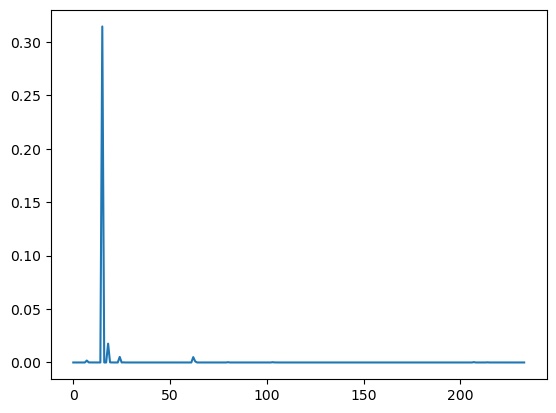

In [44]:
plt.plot(target)